In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi 
from scipy.spatial import ConvexHull
from skimage import io, color, filters, util, data, transform, feature

IMAGE INPUT

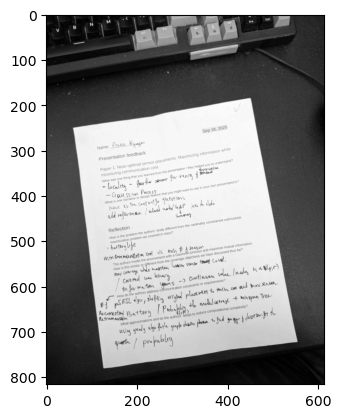

In [2]:
img_og = util.img_as_float32(io.imread('./HW01_2_test.jpg'))
img = color.rgb2gray(img_og)
img = transform.rescale(img, 1/5)
plt.imshow(img, cmap='gray')
plt.show()

EDGE DETECTION

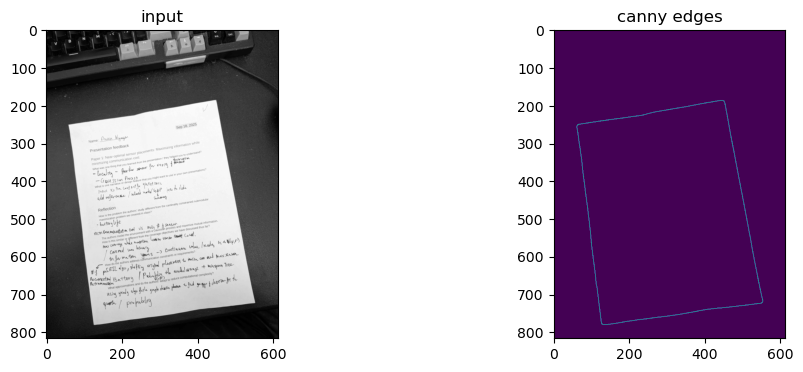

In [3]:
edges = feature.canny(img, sigma=4, low_threshold=0.1, high_threshold=0.5)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax[0].imshow(img, cmap="gray")
ax[0].set_title("input")
ax[1].imshow(edges)
ax[1].set_title("canny edges")
plt.show()

CORNER DETECTION

In [4]:
def harris_corner_detector(image, alpha=0.05, threshold=1e-3, window_size=3, sigma=1.0):
    # 1. Compute image derivatives
    Ix = filters.sobel_h(image) # compute horizontal derivative (x-direction)
    Iy = filters.sobel_v(image) # compute vertical derivative (y-direction)

    # 2. Compute products of derivatives
    Ixx = np.multiply(Ix, Ix) # Compute using hadamard product
    Iyy = np.multiply(Iy, Iy)# Compute using hadamard product
    Ixy = np.multiply(Ix, Iy)# Compute using hadamard product

    # 3. Gaussian filter to smooth the squared derivatives
    Sxx = filters.gaussian(Ixx, sigma=sigma) # Gaussian filter of Ixx
    Syy = filters.gaussian(Iyy, sigma=sigma) # Gaussian filter of Iyy
    Sxy = filters.gaussian(Ixy, sigma=sigma) # Gaussian filter of Ixy

    # 4. Compute cornerness 
    detM = np.multiply(Sxx, Syy) - (Sxy ** 2) # Must be a function of only Sxx, Syy, or Sxy
    traceM = Sxx + Syy # Must be a function of only Sxx, Syy, or Sxy
    C = detM - alpha * (traceM ** 2) # C Must be a function of only detM, traceM, and alpha

    # 5. Threshold C to remove weak corners
    C_thresh = (C > threshold * C.max()) * C

    # 6. Non-maximum suppression
    win_half_size = int(window_size // 2)
    corners = []
    for y in range(win_half_size, C.shape[0]-win_half_size):
        for x in range(win_half_size, C.shape[1]-win_half_size):
            if C_thresh[y, x] == np.max(C_thresh[y-win_half_size : y+win_half_size+1,  x-win_half_size : x+win_half_size+1]):
                if C_thresh[y, x] > 0:
                    corners.append((y, x))

    return corners, C

In [5]:
# source: https://stackoverflow.com/questions/44025403/how-to-use-matplotlib-path-to-draw-polygon
def convexhull(p):
    p = np.array(p)
    hull = ConvexHull(p)
    return [(point[1], point[0]) for point in p[hull.vertices,:]]

Text(0.5, 1.0, 'Harris Corner Detection')

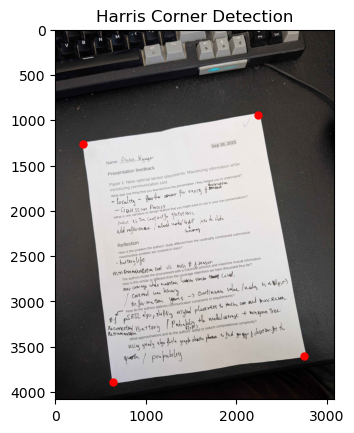

In [6]:
corners, C = harris_corner_detector(edges, alpha=0.05, threshold=0.1, window_size=3, sigma=3)
corners = np.multiply(corners, 5)
fig, ax = plt.subplots()
ax.imshow(img_og, cmap=plt.cm.gray)
y, x = zip(*corners)
ax.scatter(x, y, c='r', s=25)
ax.set_title("Harris Corner Detection")

PLOT/OUTPUT

In [7]:
def detect_document(img, scale=5):
    img_in = img
    # detect if not grayscaled already
    if img.ndim == 3:
        img_in = color.rgb2gray(img)

    # rescale
    img_in = transform.rescale(img_in, 1/scale)
    
    # edges
    edges = feature.canny(img_in, sigma=4, low_threshold=0.1, high_threshold=0.5)

    # corners
    corners = []
    sigma = 3
    while len(corners) != 4:
        corners, _ = harris_corner_detector(edges, alpha=0.05, threshold=0.1, window_size=3, sigma=sigma)
        corners = np.multiply(corners, 5)
        if len(corners) > 4:
            sigma += 0.1
        elif len(corners) < 4:
            sigma -= 0.05

    # make patches
    square = plt.Polygon(convexhull(corners), ec='orange', fc='orange', alpha=0.3, lw=3,ls='-')

    return corners, square

[[ 940 2240]
 [1265  310]
 [3600 2750]
 [3890  640]]


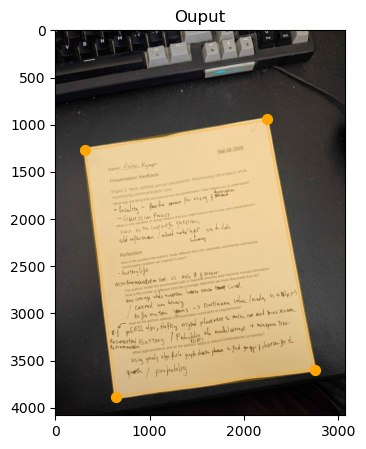

In [8]:
corners, square = detect_document(img_og, 5)
print(corners)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(img_og, cmap='gray' if img_og.ndim == 2 else None)
ax.set_title('Ouput')
y, x = zip(*corners) 
ax.scatter(x, y, c='orange', s=50)
ax.add_patch(square)
plt.show()

TRANSFORMATION TEST

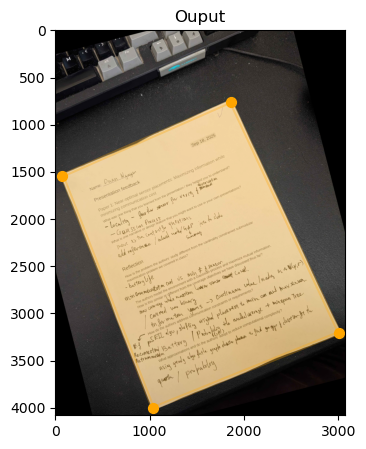

In [9]:
# rotate
tform = transform.AffineTransform(scale=(1,1), rotation=0.25, translation=(125*5,-50*5))
img2 = transform.warp(img_og, tform)
corners, square = detect_document(img2, 5)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(img2, cmap='gray' if img_og.ndim == 2 else None)
ax.set_title('Ouput')
y, x = zip(*corners) 
ax.scatter(x, y, c='orange', s=50)
ax.add_patch(square)
plt.show()

In [10]:
tform = transform.AffineTransform(scale=(1,1), rotation=0.25, translation=(125*5,-50*5))
img2 = transform.warp(img_og, tform)
img2 = color.rgb2gray(img2)
img2 = transform.rescale(img2, 1/5)

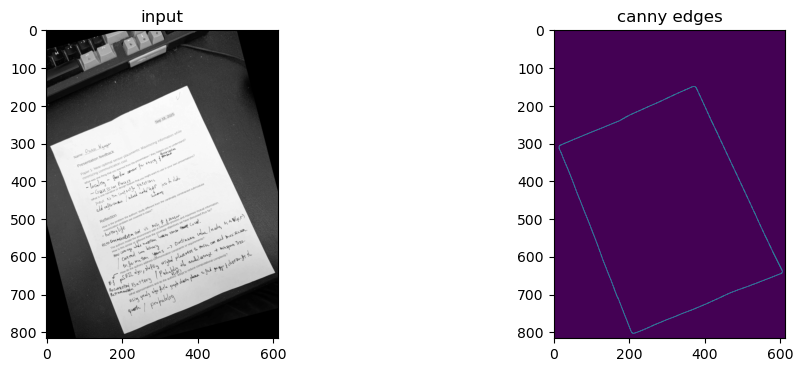

In [11]:
edges = feature.canny(img2, sigma=4, low_threshold=0.1, high_threshold=0.5)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax[0].imshow(img2, cmap="gray")
ax[0].set_title("input")
ax[1].imshow(edges)
ax[1].set_title("canny edges")
plt.show()

In [12]:
corners, _ = harris_corner_detector(edges, alpha=0.05, threshold=0.1, window_size=3, sigma=4)
corners = np.multiply(corners, 5)
corners

# make patches
# square = plt.Polygon(convexhull(corners), ec='orange', fc='orange', alpha=0.3, lw=3,ls='-')

array([[ 755, 1860],
       [1540,   75],
       [3205, 3005],
       [4005, 1040]])